# Выводы

В качестве baseline использован наивный прогноз - медиана цены по округу.
Он даёт R^2 ~ 0.12, что сильно хуже любой ML-модели  

Среди линейных моделей лучший результат показала LinearRegression:
R^2 = 0.8475. Ridge и Lasso незначительно уступают - регуляризация практически не влияет на качество. Гиперпараметры подобраны вручную. Дальнейшая оптимизация через GridSearch или байесовский поиск (Optuna) потенциально могла бы улучшить результат

Использование градиентного бустинга (CatBoost) дало прирост:
R^2 вырос с 0.8475 до 0.9165: улучшение на 7%
  
В процессе работы с линейными моделями были исправлены две методологические ошибки:
1. Заполнение пропусков без учёта типа объекта (первичка/вторичка) — признаки
   вроде `repair` или `finishing` применимы только к одному из рынков
2. Нестабильная кросс-валидация из-за OHE на высококардинальном признаке
   `nearest_station` (313 уникальных значений) - заменён на Target Encoding,
   CV стал стабильным: R^2 ~ 0.87

---

Лучший результат показал **CatBoost** с гиперпараметрами:
`iterations=1000`, `learning_rate=0.05`, `depth=6`, `early_stopping_rounds=20`.

Итоговые метрики на тестовой выборке:
- R^2 = 0.935

Кросс-валидация (5-fold, стратификация по типу объекта):
- R^2 = 0.933 ± 0.001 - модель стабильна и не переобучена

---

Наиболее значимые признаки по среднему SHAP:

1. `total_area` (0.217) - общая площадь является главным фактором. Это ожидаемо: цена квартиры в первую очередь определяется её размером
2. `distance_from_center` (0.109) - удалённость от центра Москвы. Чем дальше от центра, тем ниже цена. Тоже ожидаемо
3. `repair` (0.049) - состояние отделки. Дизайнерский и евроремонт повышают цену относительно квартир без ремонта. Подтверждается также в AB-тесте
4. `district` (0.045) - район Москвы несёт дополнительную информацию, показывает престижность района
5. `parking` (0.042) и `ceiling_height` (0.041) - наличие парковки и высота потолков являются примерными маркеры класса жилья

# Установки и Импорты

In [1]:
!pip install optuna
!pip install catboost

In [2]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

import os
from google.colab import drive
drive.mount('/content/drive')

import matplotlib
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df_start = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/мага АБД/4 модуль/df_after_eda.csv')
df_start.head()

/tmp/ipykernel_57175/1491512841.py:1: DtypeWarning: Columns (35,36,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_start = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/мага АБД/4 модуль/df_after_eda.csv')


,Unnamed: 0,url,address,price,auction,rooms_count,new_building,total_area,living_area,kitchen_area,...,seller_name,fastest_mode,fastest_minutes,nearest_station,stations_nearby,nearest_station_open,nearest_road,distance_from_mkad,roads_nearby_count,distance_from_center
0,0,https://www.cian.ru/sale/flat/324994191/,"москва, юао, р-н даниловский, м. автозаводская...",5350000,н,студия,вторичка,16.0,10.0,5.0,...,NaN,пешком,5.0,автозаводская,3.0,да,NaN,NaN,0.0,5.699610
1,1,https://www.cian.ru/sale/flat/320317503/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,16.0,13.5,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
2,2,https://www.cian.ru/sale/flat/322151830/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,15.2,12.7,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
3,6,https://www.cian.ru/sale/flat/324212999/,"москва, вао, р-н измайлово, м. измайловская, 4...",5490000,н,студия,вторичка,31.9,22.9,6.0,...,NaN,пешком,12.0,измайловская,3.0,да,NaN,NaN,0.0,11.640775
4,15,https://www.cian.ru/sale/flat/309052464/,"москва, сао, р-н ховрино, м. грачёвская, фести...",3500000,н,студия,вторичка,10.0,4.0,3.0,...,NaN,пешком,25.0,речной вокзал,3.0,да,NaN,NaN,0.0,14.052945


# Предобработка данных для ml

- **`удаляем бесполезные колонки`**: технические, которые имеют одинаковые значения - константы или почти константа, текстовые, примерные дубли
- из EDA видно, что **`целевая переменная имеет правостороннюю ассиметрию`** -> уберем 1 и 99 квантиль, а также **`логарифмируем цену`** (в ml нужно будет провести обратную операцию)
- **`заполнение попусков`** в зависимости от принадлежности признака только в первичке, только во вторичке, или к обоим
- кодировка бинарных признаков **`0` и `1`**
- **`выделение новых признаков`**, которые часто используются в фильтрах ЦИАН

In [4]:
df = df_start.copy()

In [5]:
for_drop = [
    # технические
    "Unnamed: 0", "url", "address", "description", "photos_url",
    "publication_date", "request_time",
    # текстовые сырые
    "metro_info", "highway_info", "construction_series",
    "seller", "seller_name",
    # константы / почти константа
    "auction",
    "stations_nearby",
    # дубли
    "metro_adress",           # = nearest_station
    "apartment_newbuilding",  # частично дублирует new_building
]
df.drop(columns=[c for c in for_drop if c in df.columns], inplace=True)

In [6]:
df = df.dropna(subset=["price"])
q_1  = df["price"].quantile(0.01)
q_99 = df["price"].quantile(0.99)
df = df[(df["price"] >= q_1) & (df["price"] <= q_99)]

df["log_price"] = np.log1p(df["price"])
log_target = "log_price"

df.shape

(27644, 38)

In [7]:
second = df["new_building"] == "вторичка"
new    = df["new_building"] == "новостройка"

# числовые
# только для вторичек
# заполняем 0 для новостроек
second_num = [
    "year_of_construction", "entrances", "fastest_minutes",
    "distance_from_mkad",
]
for col in second_num:
    if col in df.columns:
        median_val = df.loc[second, col].median()                 # для вторичек заполняем медианой вторичек
        df.loc[second & df[col].isna(), col] = median_val         # для новостроек ставим -1 (не применимо)
        df.loc[new & df[col].isna(), col] = -1

# числовые
# общие
# заполняем медианой по всему датасету
both_num = ["loggia_balcony"]
for col in both_num:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# категориальные
# только для вторичек
# заменяем на 'na' для новостроек
second_cat = [
    "repair", "heating", "floor_type", "gas_supply",
    "nearest_station", "nearest_station_open", "fastest_mode", "nearest_road",
]
for col in second_cat:
    if col in df.columns:
        df.loc[new & df[col].isna(), col] = "na_new_building"
        df[col] = df[col].fillna("неизвестно")

# категориальные
# только для новостроек
# заменяем на 'na' для вторичек
new_cat = ["finishing", "seller_type"]
for col in new_cat:
    if col in df.columns:
        df.loc[second & df[col].isna(), col] = "na_second_building"
        df[col] = df[col].fillna("неизвестно")

# остальные категориальные заменяем на 'неизвестно'
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("неизвестно")

# остальные числовые заменяем на медиану
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

In [8]:
bin_maps = {
    "garbage_chute":        {"Д": 1},
    "concierge":            {"Д": 1},
    "sold_with_furniture":  {"Д": 1},
    "ramp":                 {"Д": 1},
    "new_building":         {"новостройка": 1, "вторичка": 0},
    "nearest_station_open": {"да": 1, "нет": 0, "na_new_building": -1},
    "minor_owners":         {"Д": 1, "Н": 0},
    "maternity_capital":    {"Д": 1, "Н": 0},
    "accident_rate":        {"Д": 1, "Н": 0, "nan": 0},
}
for col, mapping in bin_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).fillna(0).astype(int)

In [9]:
# выделим еще признаки, которые используются в фильтрах ЦИАН
# явлыяется ли этаж первым/последним
# количество комнат преобразуем в числа для определения площади на комнату
df["is_first"]  = (df["floor"] == 1).astype(int)
df["is_last"]   = (df["floor"] == df["total_floors"]).astype(int)
rooms_num = pd.to_numeric(df["rooms_count"], errors="coerce").fillna(1)
df["area_per_room"] = df["total_area"] / rooms_num

# Трансформируем признаки

In [10]:
# группируем все получившиеся колонки по своим категориям

num_clmn = [
    "total_area", "living_area", "kitchen_area", "ceiling_height",
    "floor", "total_floors", "combined_bathroom", "separated_bathroom",
    "loggia_balcony", "year_of_construction", "passenger_elevator",
    "cargo_elevator", "entrances", "fastest_minutes",
    "distance_from_mkad", "roads_nearby_count", "distance_from_center",
    "lat", "lng",
    # новые
    "is_first", "is_last", "area_per_room",
]

# низкая кардинальность: для OHE
cat_ohe_clmn = [
    "house_type", "view_from_the_windows", "repair", "heating",
    "parking", "apartment", "floor_type", "finishing",
    "rooms_count", "okrug", "seller_type",
    "fastest_mode", "nearest_road", "nearest_station_open",
]

# высокая кардинальность: для Target Encoding
cat_te_clmn = ["nearest_station", "district"]

bin_clmn = [
    "garbage_chute", "concierge", "sold_with_furniture", "ramp",
    "new_building", "minor_owners", "maternity_capital", "accident_rate",
]

num_clmn     = [c for c in num_clmn if c in df.columns]
cat_ohe_clmn = [c for c in cat_ohe_clmn if c in df.columns]
cat_te_clmn  = [c for c in cat_te_clmn if c in df.columns]
bin_clmn     = [c for c in bin_clmn if c in df.columns]
all_clmn     = num_clmn + cat_ohe_clmn + cat_te_clmn + bin_clmn

In [11]:
X = df[all_clmn]
y = df[log_target]   # предсказываем логарифм.цену

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# переводим цену обратно в рубли
price_test = np.expm1(y_test)

print(X_train.shape)
print(X_test.shape)

(22115, 39)
(5529, 39)


In [12]:
# собираем кодировку признаков в единый пайплайн

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                                             num_clmn),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False),  cat_ohe_clmn),
    ("te",  TargetEncoder(target_type="continuous", smooth="auto"),       cat_te_clmn), # TargetEncoder внутри CV сам делает кодирование без утечки
    ("bin", "passthrough",                                                bin_clmn),
])

# Обучаем модели

## линейная регрессия

In [13]:
pipe_lr = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
pipe_lr.fit(X_train, y_train)

log_pred_lr = pipe_lr.predict(X_test)
price_pred_lr = np.expm1(log_pred_lr)   # преобразоваем лог. обратно в нормальные рубли

mae_lr = mean_absolute_error(price_test, price_pred_lr)
rmse_lr = mean_squared_error(price_test, price_pred_lr) ** 0.5
r2_log_lr = r2_score(y_test, log_pred_lr)
r2_rub_lr = r2_score(price_test, price_pred_lr)
mape_lr = np.abs((price_test - price_pred_lr) / price_test).mean() * 100

print(f"MAE       = {mae_lr:,.0f} руб.")
print(f"RMSE      = {rmse_lr:,.0f} руб.")
print(f"MAPE      = {mape_lr:.2f} %")
print(f"R^2 (log) = {r2_log_lr:.4f}")
print(f"R^2 (руб) = {r2_rub_lr:.4f}")

MAE       = 3,048,147 руб.
RMSE      = 4,440,050 руб.
MAPE      = 12.42 %
R^2 (log) = 0.8791
R^2 (руб) = 0.8417


## ridge

In [14]:
pipe_ridge = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=10))])
pipe_ridge.fit(X_train, y_train)

log_pred_ridge = pipe_ridge.predict(X_test)
price_pred_ridge = np.expm1(log_pred_ridge)

mae_ridge = mean_absolute_error(price_test, price_pred_ridge)
rmse_ridge = mean_squared_error(price_test, price_pred_ridge) ** 0.5
r2_log_ridge = r2_score(y_test, log_pred_ridge)
r2_rub_ridge = r2_score(price_test, price_pred_ridge)
mape_ridge = np.abs((price_test - price_pred_ridge) / price_test).mean() * 100

print(f"Ridge (alpha=10)")
print(f"MAE       = {mae_ridge:,.0f} руб.")
print(f"RMSE      = {rmse_ridge:,.0f} руб.")
print(f"MAPE      = {mape_ridge:.2f} %")
print(f"R^2 (log) = {r2_log_ridge:.4f}")
print(f"R^2 (руб) = {r2_rub_ridge:.4f}")

Ridge (alpha=10)
MAE       = 3,092,455 руб.
RMSE      = 4,519,188 руб.
MAPE      = 12.53 %
R^2 (log) = 0.8772
R^2 (руб) = 0.8360


## lasso

In [15]:
pipe_lasso = Pipeline([("prep", preprocessor), ("model", Lasso(alpha=1e-3, max_iter=10000))])
pipe_lasso.fit(X_train, y_train)

log_pred_lasso = pipe_lasso.predict(X_test)
price_pred_lasso = np.expm1(log_pred_lasso)

mae_lasso = mean_absolute_error(price_test, price_pred_lasso)
rmse_lasso = mean_squared_error(price_test, price_pred_lasso) ** 0.5
r2_log_lasso = r2_score(y_test, log_pred_lasso)
r2_rub_lasso = r2_score(price_test, price_pred_lasso)
mape_lasso = np.abs((price_test - price_pred_lasso) / price_test).mean() * 100

print(f"MAE       = {mae_lasso:,.0f} руб.")
print(f"RMSE      = {rmse_lasso:,.0f} руб.")
print(f"MAPE      = {mape_lasso:.2f} %")
print(f"R^2 (log) = {r2_log_lasso:.4f}")
print(f"R^2 (руб) = {r2_rub_lasso:.4f}")

MAE       = 3,209,265 руб.
RMSE      = 4,744,322 руб.
MAPE      = 12.93 %
R^2 (log) = 0.8683
R^2 (руб) = 0.8192


## сохраняем результат моделей

In [16]:
fitted = {
    "LinearRegression": pipe_lr,
    "Ridge (alpha=10)": pipe_ridge,
    "Lasso (alpha=1e-3)": pipe_lasso
}

fitted

{'LinearRegression': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['total_area', 'living_area',
                                                    'kitchen_area',
                                                    'ceiling_height', 'floor',
                                                    'total_floors',
                                                    'combined_bathroom',
                                                    'separated_bathroom',
                                                    'loggia_balcony',
                                                    'year_of_construction',
                                                    'passenger_elevator',
                                                    'cargo_elevator',
                                                    'entrances',
                                                    'fastest_minutes',
         

## кросс валидация лучшей модели

Лучший результат показала линейная регрессия по метрике R^2  
Проверим результат на кросс валидаци

p.s. в первый раз кросс валидация показала отрицательные значения для целевой метрики, чтоб устранить ошибку было использовано
- другая кодировка для категориальных признаков : высоко и низко кардинальные признаки трансоформировались своими методами
- добавлена стратификация, чтоб соотношение вторичек и первичек в фолде было примерно одинаковым

In [17]:
lr_pipe = Pipeline([("prep", preprocessor), ("model", LinearRegression())])

# стратифицируем по типу объекта, чтобы доля новостроек в фолдах была одинакова
strat_col = df.loc[X.index, "new_building"]   # 0/1 после бинарного кодирования
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv = cross_val_score(lr_pipe, X, y, cv=skf.split(X, strat_col), scoring="r2", n_jobs=-1)

print(f"R^2 по фолдам: {[round(s, 4) for s in cv]}")

R^2 по фолдам: [np.float64(0.8818), np.float64(0.8785), np.float64(0.8798), np.float64(0.8795), np.float64(0.888)]


## Коэф. линейной регрессии

У линейной регрессии вместо SHAP использовались коэффициенты модели. Они показывают, на сколько изменится log_price если признак вырастет на 1 единицу при фиксированных остальных

В отличие от SHAP, коэффициенты работают только для линейных моделей и не учитывают взаимодействия между признаками

In [18]:
lr_pipe.fit(X_train, y_train)
ohe_names = (lr_pipe.named_steps["prep"]
             .named_transformers_["ohe"]
             .get_feature_names_out(cat_ohe_clmn))
te_names = cat_te_clmn
feature_names = num_clmn + list(ohe_names) + te_names + bin_clmn

coef_df = (pd.DataFrame({"feature": feature_names,
                          "coef": lr_pipe.named_steps["model"].coef_})
           .assign(abs_coef=lambda d: d["coef"].abs())
           .sort_values("abs_coef", ascending=False))

print(coef_df.head(20)[["feature", "coef"]].to_string(index=False))

                       feature      coef
          year_of_construction  2.175745
                  new_building  0.417298
       heating_na_new_building  0.417298
        repair_na_new_building  0.417298
    floor_type_na_new_building  0.417298
  finishing_na_second_building -0.417298
seller_type_na_second_building -0.417298
  fastest_mode_na_new_building  0.417298
       nearest_station_open_-1  0.417298
  nearest_road_na_new_building  0.417298
            rooms_count_студия -0.374296
                 rooms_count_4  0.372656
                 rooms_count_1 -0.298538
                      district  0.254904
                 rooms_count_3  0.244030
         floor_type_неизвестно -0.231161
        seller_type_застройщик  0.224250
                   okrug_зелао  0.218605
        nearest_station_open_1 -0.213111
                  okrug_другое  0.204863


# Улучшение модели c помощью CatBoost

## подготовка признаков

In [19]:
num_clmn_cat = [
    "total_area", "living_area", "kitchen_area", "ceiling_height",
    "floor", "total_floors", "combined_bathroom", "separated_bathroom",
    "loggia_balcony", "year_of_construction", "passenger_elevator",
    "cargo_elevator", "entrances", "fastest_minutes",
    "distance_from_mkad", "roads_nearby_count", "distance_from_center",
    "lat", "lng",
    "is_first", "is_last", "area_per_room",
]

# катбуст принимает категории как есть - кодировки не нужны
cat_clmn_cat = [
    "house_type", "view_from_the_windows", "repair", "heating",
    "parking", "apartment", "floor_type", "finishing",
    "rooms_count", "okrug", "district", "nearest_station", "seller_type",
    "fastest_mode", "nearest_road",
]

bin_clmn_cat = [
    "garbage_chute", "concierge", "sold_with_furniture", "ramp",
    "new_building", "minor_owners", "maternity_capital", "accident_rate",
    "nearest_station_open",
]

num_cols = [c for c in num_clmn_cat if c in df.columns]
cat_cols = [c for c in cat_clmn_cat if c in df.columns]
bin_cols = [c for c in bin_clmn_cat if c in df.columns]
all_features = num_cols + cat_cols + bin_cols

# все признаки в категориях должны быть строками (катбуст требует)
for c in cat_cols:
    df[c] = df[c].astype(str)

In [20]:
X = df[all_features].copy()
y = df[log_target]

strat = df.loc[X.index, "new_building"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strat
)

price_test = np.expm1(y_test)
# переменная с индексами для катбуста
cat_idx = cat_cols

print(X_train.shape)
print(X_test.shape)

(22115, 39)
(5529, 39)


## обучение модели

In [21]:
base_cb = CatBoostRegressor(
    iterations=1000,          # максимальное количество деревьев
    learning_rate=0.05,       # шаг обучения - насколько каждое дерево влияет на результат
    depth=6,                  # глубина каждого дерева
    loss_function="RMSE",     # функция потерь при обучении
    eval_metric="R2",         # метрика для отслеживания на eval_set
    random_seed=42,           # фиксируем случайность для воспроизводимости
    verbose=False,            # не печатать лог обучения на каждой итерации
    early_stopping_rounds=20, # остановить обучение если метрика не улучшается 20 итераций подряд
)

base_cb.fit(
    X_train, y_train,
    cat_features=cat_idx,     # индексы категориальных признаков
    eval_set=(X_test, y_test), # данные для отслеживания метрики в процессе обучения
)

CatBoostRegressor(depth=6, early_stopping_rounds=20, eval_metric='R2', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [22]:
y_rub_pred = np.expm1(base_cb.predict(X_test))

mae  = mean_absolute_error(price_test, y_rub_pred)
rmse = mean_squared_error(price_test, y_rub_pred) ** 0.5
mape = np.abs((price_test - y_rub_pred) / price_test).mean() * 100
r2l  = r2_score(y_test, base_cb.predict(X_test))
r2r  = r2_score(price_test, y_rub_pred)

print(f"MAE       = {mae:,.0f} руб.")
print(f"RMSE      = {rmse:,.0f} руб.")
print(f"MAPE      = {mape:.2f} %")
print(f"R^2 (log) = {r2l:.4f}")
print(f"R^2 (руб) = {r2r:.4f}")

MAE       = 2,263,651 руб.
RMSE      = 3,348,529 руб.
MAPE      = 9.05 %
R^2 (log) = 0.9353
R^2 (руб) = 0.9165


## кросс валидация

In [23]:
# не работает (какая-то несовместимость), напишем цикл вручную

#cb_cv = CatBoostRegressor(
#    iterations=1000,
#    learning_rate=0.05,
#    depth=6,
#    loss_function="RMSE",
#    eval_metric="R2",
#    random_seed=42,
#    verbose=False,
#    early_stopping_rounds=20,
#    cat_features=cat_idx,
#)
#
#strat_col = df.loc[X.index, "new_building"]
#skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#
#cv = cross_val_score(cb_cv, X, y, cv=skf.split(X, strat_col), scoring="r2", n_jobs=-1)
#
#print(f"R^2 по фолдам: {[round(s, 4) for s in cv]}")

In [24]:
strat_full = df.loc[X.index, "new_building"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, strat_full)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        eval_metric="R2",
        random_seed=42,
        verbose=False,
        early_stopping_rounds=20,
    )
    m.fit(Pool(X_tr, y_tr, cat_features=cat_idx),
          eval_set=Pool(X_val, y_val, cat_features=cat_idx))
    cv_scores.append(r2_score(y_val, m.predict(X_val)))
    print(f"Фолд {fold+1}: R^2 = {cv_scores[-1]:.4f}")

cv_arr = np.array(cv_scores)

Фолд 1: R^2 = 0.9337
Фолд 2: R^2 = 0.9324
Фолд 3: R^2 = 0.9332
Фолд 4: R^2 = 0.9343
Фолд 5: R^2 = 0.9381


## shape

In [25]:
shap_values = base_cb.get_feature_importance(
    Pool(X_test, cat_features=cat_idx),
    type="ShapValues"
)[:, :-1]   # последний столбец - baseline, дропаем его

shap_df = pd.DataFrame({
    "feature":    all_features,
    "mean_shap":  np.abs(shap_values).mean(axis=0),
}).sort_values("mean_shap", ascending=False)

print("Топ-20 признаков по SHAP:")
print(shap_df.head(20).to_string(index=False))

Топ-20 признаков по SHAP:
             feature  mean_shap
          total_area   0.216603
distance_from_center   0.108829
              repair   0.048810
            district   0.045424
             parking   0.041775
      ceiling_height   0.041037
               okrug   0.036810
                 lng   0.026743
year_of_construction   0.024626
         rooms_count   0.024210
        kitchen_area   0.022273
                 lat   0.014907
        total_floors   0.013759
     fastest_minutes   0.011248
         seller_type   0.010748
          house_type   0.009236
          floor_type   0.008607
               floor   0.008321
      cargo_elevator   0.008034
           finishing   0.007532


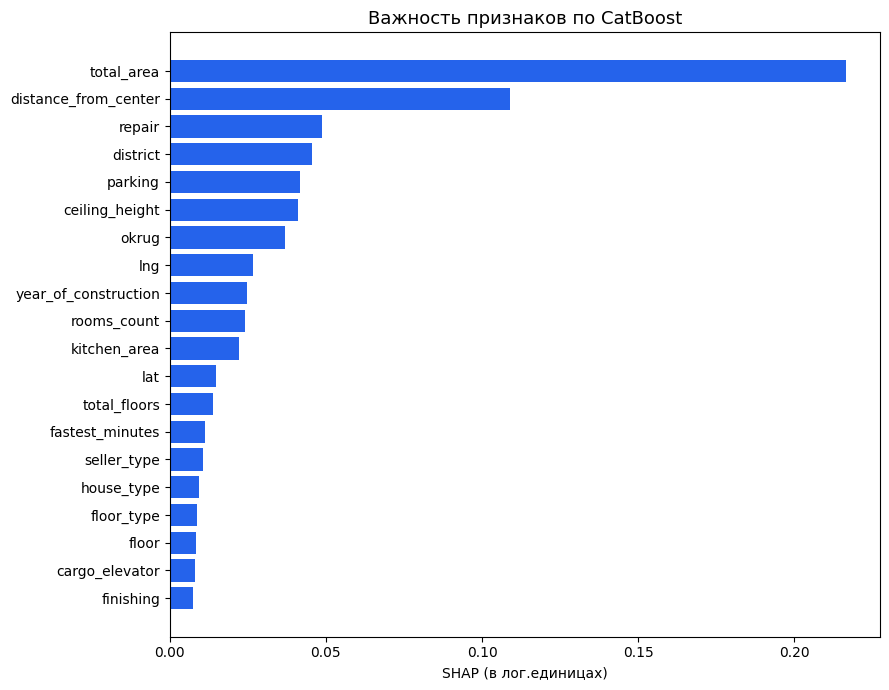

In [26]:
# модель обучалась на log(price), поэтому SHAP тоже в таких же единицах измерения
# среднее SHAP показывает, насколько в среднем каждый признак сдвигает таргет
# чем больше значение, тем важнее признак для предсказания

top20 = shap_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20["feature"], top20["mean_shap"], color="#2563eb")
ax.set_xlabel("SHAP (в лог.единицах)")
ax.set_title("Важность признаков по CatBoost", fontsize=13)
plt.tight_layout()
plt.show()

# Сравнение моделей

## baseline

In [27]:
#медиана цены по округу
okrug_median = df.groupby("okrug")["price"].median()
naive_pred = df.loc[X_test.index, "okrug"].map(okrug_median)
# если какой-то округ не встретился в train - заполняем общей медианой
naive_pred = naive_pred.fillna(df["price"].median())

naive_mae  = mean_absolute_error(price_test, naive_pred)
naive_rmse = mean_squared_error(price_test, naive_pred) ** 0.5
naive_mape = np.abs((price_test - naive_pred) / price_test).mean() * 100
naive_r2   = r2_score(price_test, naive_pred)

print("Наивный прогноз (медиана по округу):")
print(f"MAE      = {naive_mae:,.0f} руб.")
print(f"RMSE     = {naive_rmse:,.0f} руб.")
print(f"MAPE     = {naive_mape:.2f} %")
print(f"R^2      = {naive_r2:.4f}")

Наивный прогноз (медиана по округу):
MAE      = 8,308,316 руб.
RMSE     = 10,861,991 руб.
MAPE     = 36.86 %
R^2      = 0.1210


## сравнение всех моделей

In [28]:
models_to_compare = {
    "LinearRegression":  fitted["LinearRegression"],
    "Ridge (alpha=10)":  fitted["Ridge (alpha=10)"],
    "Lasso (alpha=1e-3)": fitted["Lasso (alpha=1e-3)"],
    "CatBoost (базовый)": base_cb,
}

rows = []
for name, model in models_to_compare.items():
    if name == "CatBoost (базовый)":
        y_log_pred = model.predict(X_test)
    else:
        y_log_pred = model.predict(X_test[all_clmn])

    y_rub_pred = np.expm1(y_log_pred)

    rows.append({
        "Модель":   name,
        "MAE":      mean_absolute_error(price_test, y_rub_pred),
        "RMSE":     mean_squared_error(price_test, y_rub_pred) ** 0.5,
        "MAPE, %":  np.abs((price_test - y_rub_pred) / price_test).mean() * 100,
        "R^2 (log)": r2_score(y_test, y_log_pred),
        "R^2 (руб)": r2_score(price_test, y_rub_pred)
    })

results_df = pd.DataFrame(rows).set_index("Модель")
results_df = results_df.round({
    "MAE": 0, "RMSE": 0, "MAPE, %": 2,
    "R^2 (log)": 4, "R^2 (руб)": 4
})

naive_row = {
    "Модель":    "Наивный (медиана по округу)",
    "MAE":       naive_mae,
    "RMSE":      naive_rmse,
    "MAPE, %":   naive_mape,
    "R^2 (log)": np.nan,
    "R^2 (руб)": naive_r2,
}
results_df_full = pd.concat([
    pd.DataFrame([naive_row]).set_index("Модель"),
    results_df
])
results_df_full = results_df_full.round({
    "MAE": 0, "RMSE": 0, "MAPE, %": 2,
    "R^2 (log)": 4, "R^2 (руб)": 4
})

results_df_full

,MAE,RMSE,"MAPE, %",R^2 (log),R^2 (руб)
Модель,,,,,
Наивный (медиана по округу),8308316.0,10861991.0,36.86,NaN,0.1210
LinearRegression,3104281.0,4523992.0,12.39,0.8857,0.8475
Ridge (alpha=10),3143032.0,4592002.0,12.48,0.8845,0.8429
Lasso (alpha=1e-3),3263752.0,4829829.0,12.87,0.8771,0.8262
CatBoost (базовый),2263651.0,3348529.0,9.05,0.9353,0.9165
